<a href="https://colab.research.google.com/github/sathaniya-m/Student-Performance-Analytics/blob/main/Studentperformance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
from google.colab import files
uploaded=files.upload()

Saving student_marks.csv to student_marks (2).csv


In [62]:
import pandas as pd
df=pd.read_csv('student_marks.csv')
print(df.head())

  Student_name  Tamil  English  Python  Java  C++
0    Sathaniya     90       87      78    96   77
1       Smitha     21       85      90    85   46
2        Priya     88       53      53    68   22
3     Manushri     93       24      88    57   46
4      Karthik     57       86      23    55   25


In [63]:
subjects = ['Tamil','English','Python','Java','C++']

df['Total_Marks'] = df[subjects].sum(axis=1)
df['Average'] = df[subjects].mean(axis=1)

print(df[['Student_name','Total_Marks','Average']])

  Student_name  Total_Marks  Average
0    Sathaniya          428     85.6
1       Smitha          327     65.4
2        Priya          284     56.8
3     Manushri          308     61.6
4      Karthik          246     49.2


In [64]:
def assign_grade(avg):
    if avg >= 90:
        return 'A+'
    elif avg >= 80:
        return 'A'
    elif avg >= 70:
        return 'B'
    elif avg >= 60:
        return 'C'
    elif avg >= 50:
        return 'D'
    else:
        return 'F'

df['Grade'] = df['Average'].apply(assign_grade)

df['Status'] = np.where(df['Average'] >= 50, 'Pass', 'Fail')

print(df[['Student_name','Average','Grade','Status']])

  Student_name  Average Grade Status
0    Sathaniya     85.6     A   Pass
1       Smitha     65.4     C   Pass
2        Priya     56.8     D   Pass
3     Manushri     61.6     C   Pass
4      Karthik     49.2     F   Fail


In [65]:
topper = df.loc[df['Average'].idxmax()]

print("Top Performer")
print("Name:", topper['Student_name'])
print("Average:", topper['Average'])
print("Grade:", topper['Grade'])

Top Performer
Name: Sathaniya
Average: 85.6
Grade: A


In [66]:
weak_students = df[df['Status'] == 'Fail']

print("Weak Students")
print(weak_students[['Student_name','Average']])

Weak Students
  Student_name  Average
4      Karthik     49.2


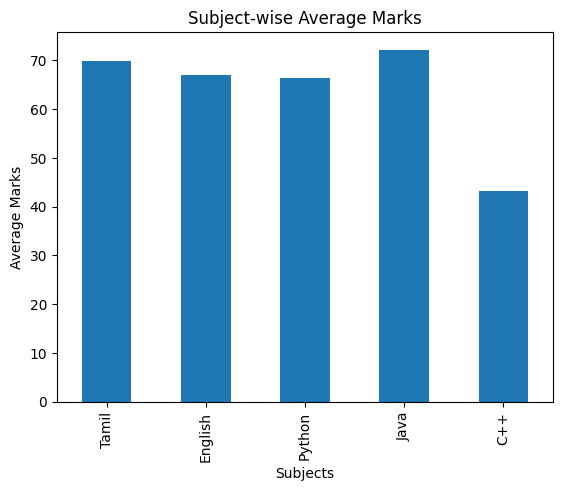

In [67]:
subject_avg = df[['Tamil','English','Python','Java','C++']].mean()

subject_avg.plot(kind='bar')

plt.title("Subject-wise Average Marks")
plt.xlabel("Subjects")
plt.ylabel("Average Marks")
plt.show()

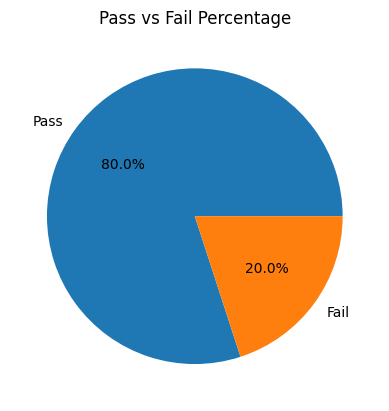

In [68]:
status_count = df['Status'].value_counts()

plt.pie(status_count,
        labels=status_count.index,
        autopct='%1.1f%%')

plt.title("Pass vs Fail Percentage")
plt.show()

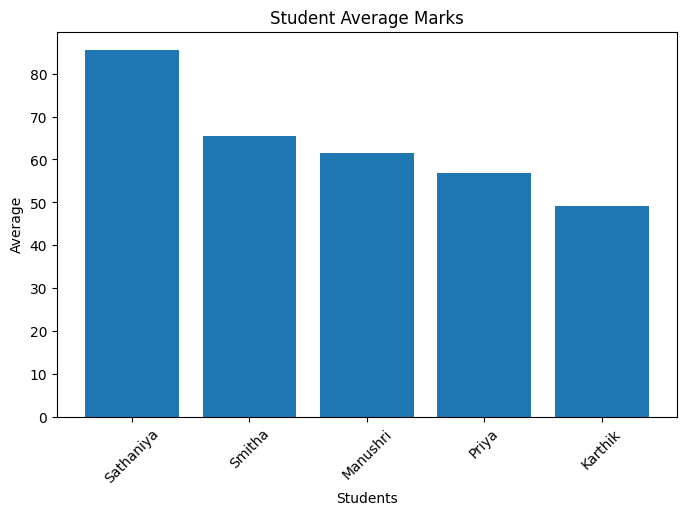

In [70]:
top_students = df.sort_values(by='Average', ascending=False)

plt.figure(figsize=(8,5))
plt.bar(top_students['Student_name'],
        top_students['Average'])

plt.title("Student Average Marks")
plt.xlabel("Students")
plt.ylabel("Average")
plt.xticks(rotation=45)

plt.show()

In [71]:
print("Highest Performing Subject:",
      subject_avg.idxmax())

print("Lowest Performing Subject:",
      subject_avg.idxmin())

print("Pass Percentage:",
      round((df['Status']=='Pass').mean()*100,2),"%")

print("Class Average:",
      round(df['Average'].mean(),2))

Highest Performing Subject: Java
Lowest Performing Subject: C++
Pass Percentage: 80.0 %
Class Average: 63.72
